In [1]:
library(tidyverse)
library(ggplot2)
library(lubridate)
library(zoo)

Warning message:
"package 'tidyverse' was built under R version 4.4.2"
Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




In [2]:
crime_all <- read_csv("Original_Crime_data/crime_in_vancouver.csv")|>
    rename("type" = "TYPE", "neighbourhood" = "NEIGHBOURHOOD")|>
    mutate(date = as.Date(paste(YEAR, MONTH, DAY, sep = "-")))|>
    filter(!is.na(time_category))|>
    select(type, date, YEAR, MONTH, neighbourhood, geometry, time_category)|>
    glimpse()

Rows: 409167 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): TYPE, HUNDRED_BLOCK, NEIGHBOURHOOD, geometry, time_category
dbl  (5): YEAR, MONTH, DAY, HOUR, MINUTE
dttm (3): crime_datetime, sunrise, sunset
date (1): date_only

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 409,147
Columns: 7
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ date          <date> 2019-03-07, 2020-07-28, 2021-11-21, 2022-01-05, 2005-11…
$ YEAR          <dbl> 2019, 2020, 2021, 2022, 2005, 2006, 2009, 2014, 2022, 20…
$ MONTH         <dbl> 3, 7, 11, 1, 11, 5, 7, 9, 1, 11, 3, 5, 11, 11, 3, 9, 1, …
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ geometry      <chr> "c(-123.129029239886, 49.2666781434274)", "c(-123.123536…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


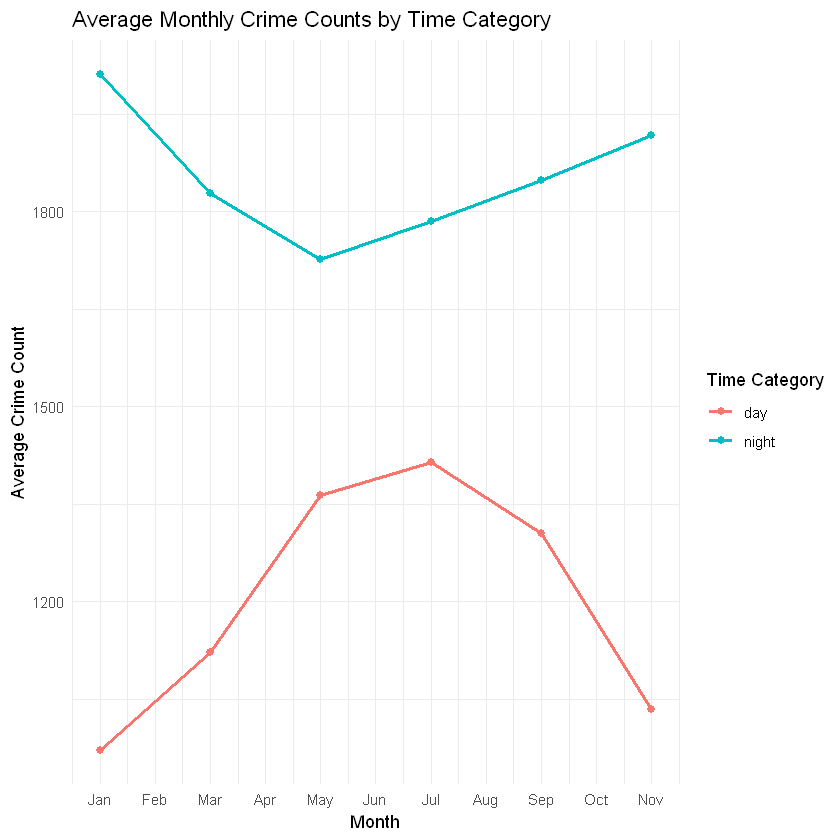

In [3]:
monthly_counts <- crime_all|>
  group_by(time_category, YEAR, MONTH)|>
  summarise(crime_count = n(), .groups = "drop")

avg_monthly_counts <- monthly_counts %>%
  group_by(time_category, MONTH) %>%
  summarise(avg_crime = mean(crime_count), .groups = "drop")|>
  filter(!is.na(time_category))

ggplot(avg_monthly_counts, aes(x = MONTH, y = avg_crime, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  labs(x = "Month", y = "Average Crime Count", 
       title = "Average Monthly Crime Counts by Time Category",
       color = "Time Category") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 4 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`)."


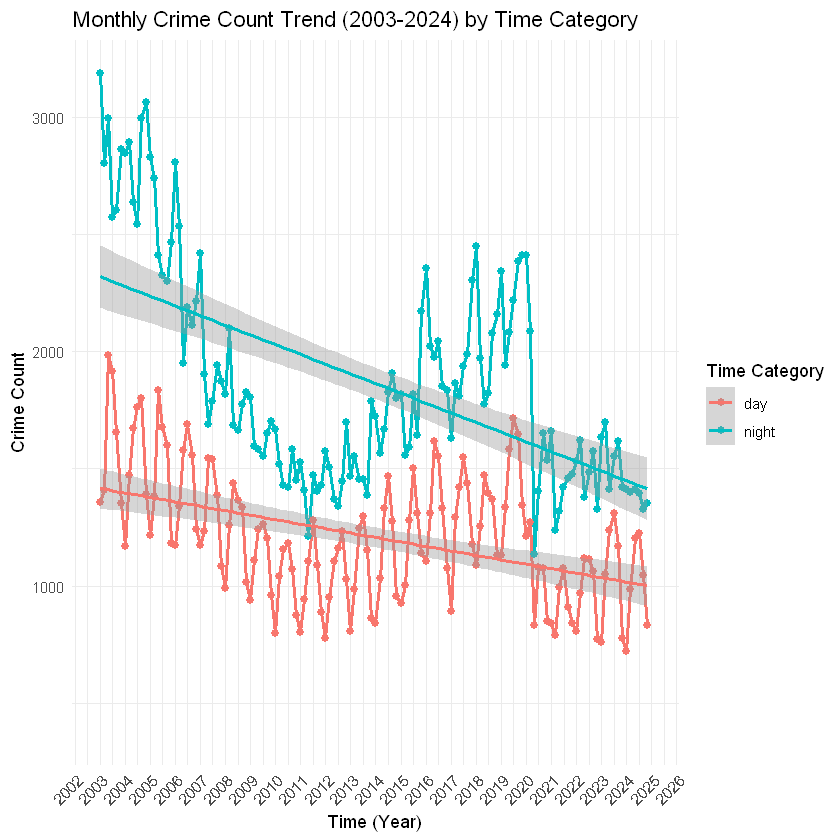

In [11]:
crime_trend <- crime_all|>
    group_by(time_category, YEAR, MONTH)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(YEAR, MONTH, "01", sep = "-")))

ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 160 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 160 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 160 rows containing missing values or values outside the scale range
(`geom_point()`)."


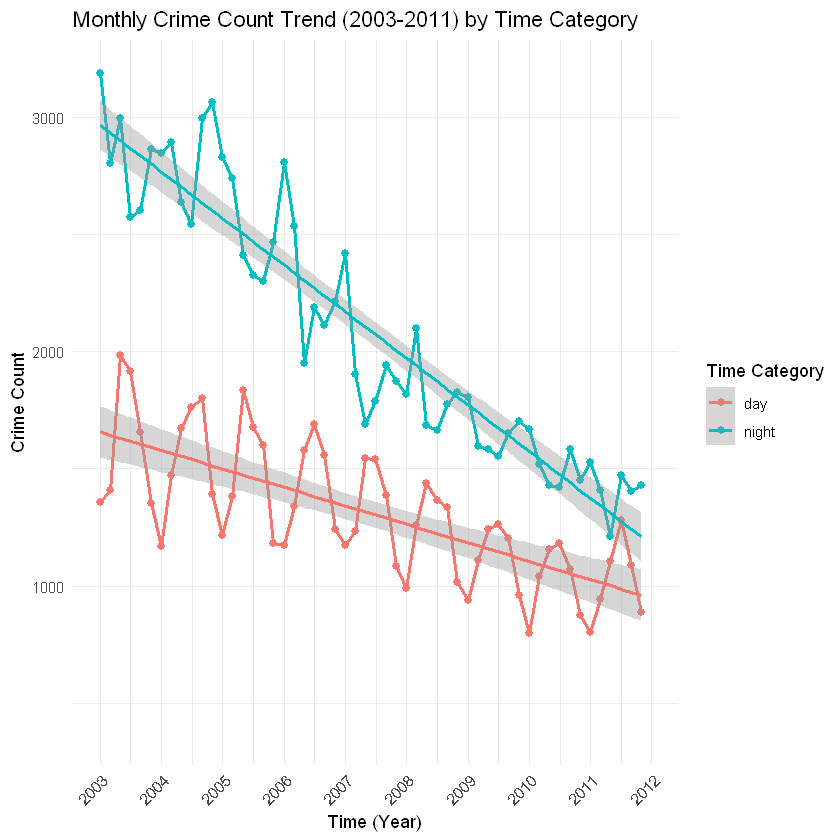

In [12]:
ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2011-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2011) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 124 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 124 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 124 rows containing missing values or values outside the scale range
(`geom_point()`)."


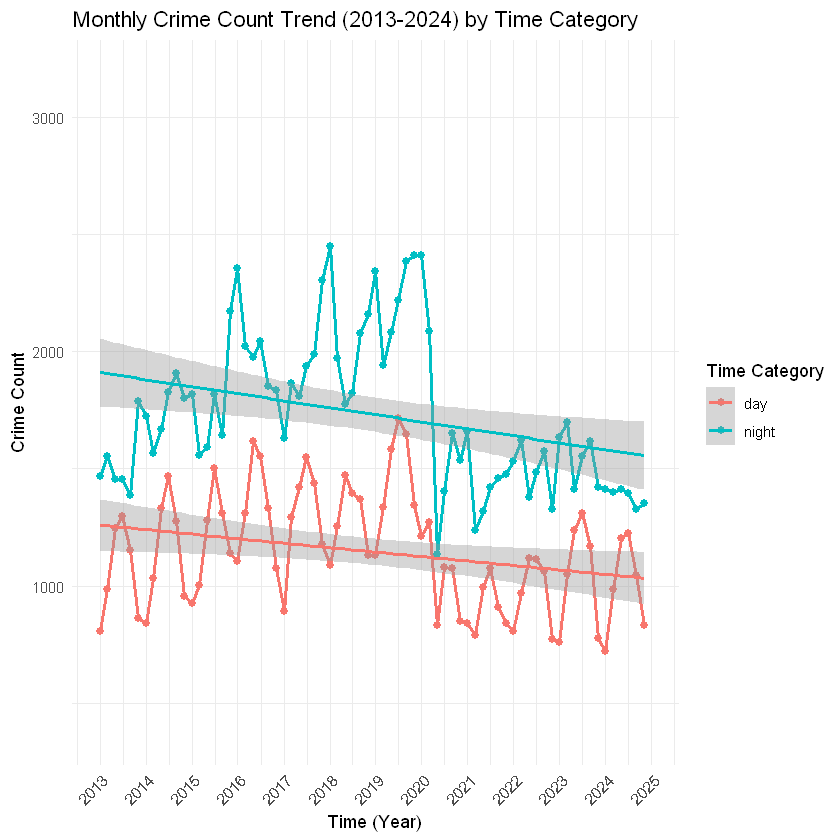

In [13]:
ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [15]:
lum_data <- read_csv("NTL_data/ntl_vancouver_monthly_total_ntl.csv")|>
    glimpse()

Rows: 78 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): total_ntl, total_pixels, weighted_ntl_mean, prev_weighted_ntl_mean
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 78
Columns: 5
$ date                   <date> 2012-01-01, 2012-03-01, 2012-05-01, 2012-07-01…
$ total_ntl              <dbl> NA, 9.5066512, -3.7940151, 1.8771791, 9.7744734…
$ total_pixels           <dbl> 3650, 3853, 3868, 3868, 3868, 3434, 3862, 3861,…
$ weighted_ntl_mean      <dbl> 4.522459, 4.952393, 4.764499, 4.853937, 5.32838…
$ prev_weighted_ntl_mean <dbl> NA, 4.522459, 4.952393, 4.764499, 4.853937, 5.3…


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


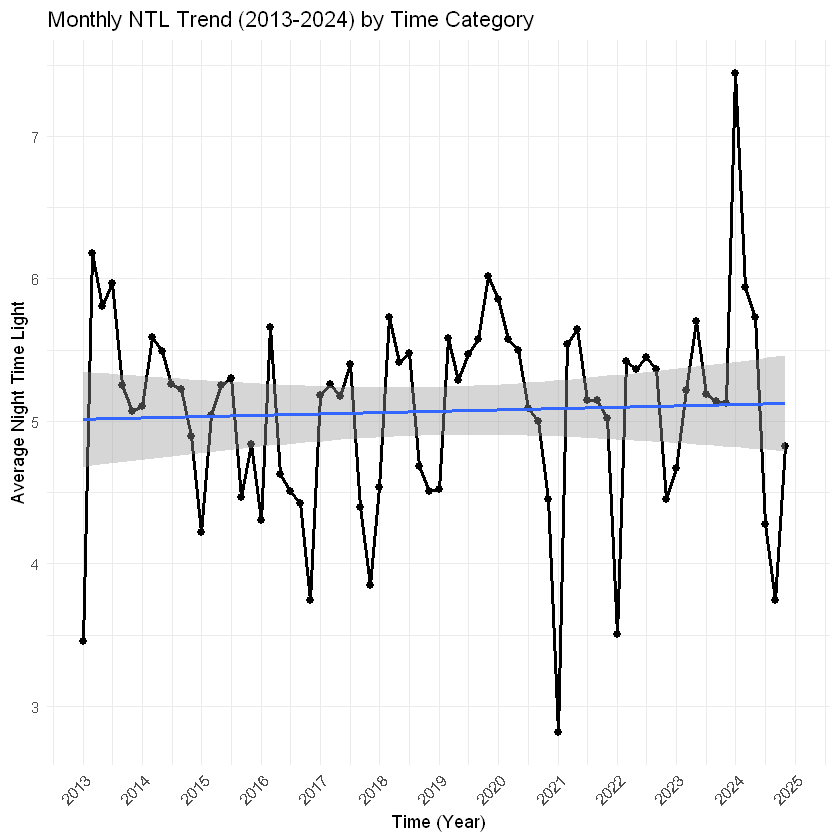

In [16]:
ggplot(lum_data, aes(x = date, y = weighted_ntl_mean)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

,date,time_category,YEAR,MONTH,crime_count,total_ntl,total_pixels,weighted_ntl_mean,prev_weighted_ntl_mean
,<date>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,2012-01-01,day,2012,1,774,NA,3650,4.522459,NA
2,2012-01-01,night,2012,1,1573,NA,3650,4.522459,NA
3,2012-03-01,day,2012,3,952,9.506651,3853,4.952393,4.522459
4,2012-03-01,night,2012,3,1506,9.506651,3853,4.952393,4.522459
5,2012-05-01,day,2012,5,1103,-3.794015,3868,4.764499,4.952393
6,2012-05-01,night,2012,5,1368,-3.794015,3868,4.764499,4.952393



Call:
lm(formula = crime_count ~ weighted_ntl_mean, data = merged_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-738.76 -300.83  -37.36  223.70 1030.26 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1357.22     237.74   5.709 5.68e-08 ***
weighted_ntl_mean    13.78      46.68   0.295    0.768    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 406.3 on 154 degrees of freedom
Multiple R-squared:  0.0005652,	Adjusted R-squared:  -0.005925 
F-statistic: 0.08709 on 1 and 154 DF,  p-value: 0.7683


`geom_smooth()` using formula = 'y ~ x'


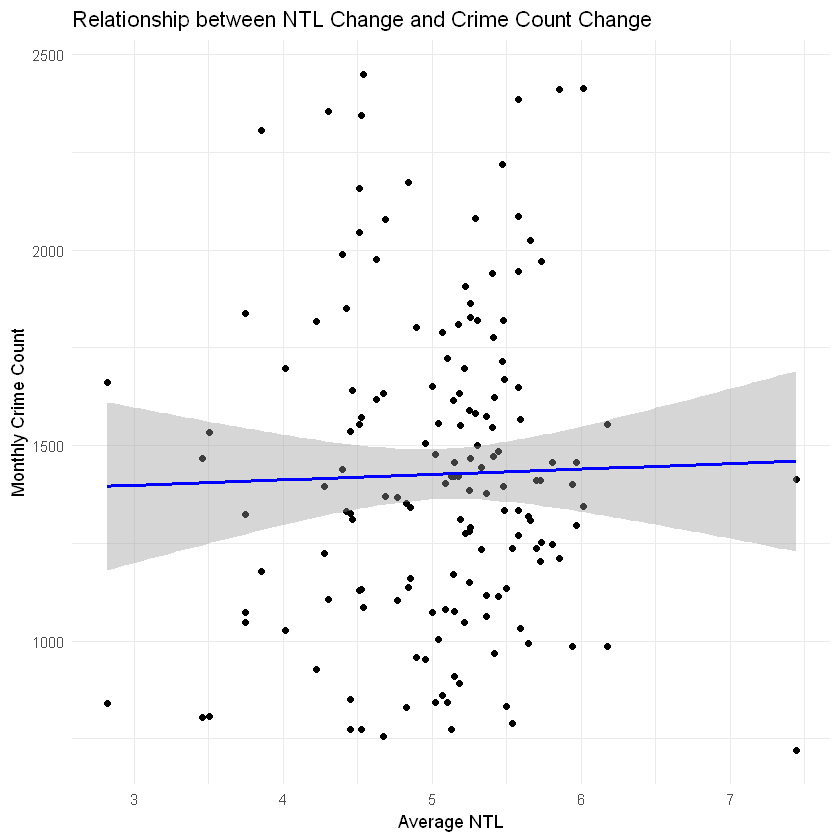

In [22]:
# Since both datasets have a date variable (format similar to "1月 2012"), we can use it to merge the data
merged_data <- merge(crime_trend, lum_data, by = "date")

# Check merge results
head(merged_data)

# Note:
# In the merged data, variables with the same name from both files will automatically get .x and .y suffixes
# Here, crime data percent change is pct_change.x, ntl is pct_change.y


# Run linear regression, using NTL percent change to predict crime rate percent change
reg_model <- lm(crime_count ~ weighted_ntl_mean, data = merged_data)
summary(reg_model)

# Create scatter plot with regression line
ggplot(merged_data, aes(x = weighted_ntl_mean, y = crime_count)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(x = "Average NTL", y = "Monthly Crime Count",
       title = "Relationship between NTL Change and Crime Count Change") +
  theme_minimal()


In [37]:
crime_summary_neighbourhood <- crime_all|>
    filter(YEAR != 2025)|>
    filter(!neighbourhood %in% c("Musqueam", "Stanley Park"))|>
    group_by(neighbourhood)|>
    summarise(crime_count = n())|>
    arrange(crime_count)

crime_summary_neighbourhood

neighbourhood,crime_count
<chr>,<int>
Shaughnessy,3929
South Cambie,4428
Arbutus Ridge,4505
West Point Grey,4522
Kerrisdale,5386
Dunbar-Southlands,5484
Oakridge,6188
Killarney,7486
Victoria-Fraserview,7812
